In [12]:
import os
import argparse
import numpy as np
import pandas as pd
from decimal import *
import matplotlib.pyplot as plt
from tqdm import tqdm

In [13]:
def update_delta(gamma_j, beta):
    return 1/gamma_j * ((gamma_j*(beta - 1) + 1)**(1/(1 - beta)))

def update_eff(n_a, E_o, S_o, delta_e, k_C, n_d):
    # if E_o - n_a* S_o is positive, the exponential value of this expression will explode in calculation.
    # The original form of efficiency formula contains negative exponent and
    # the simplified form contains the positive exponent
    
    if (E_o - n_a*S_o) >= 0:
        return n_d * (n_a - \
                        ((E_o - n_a*S_o)*n_a*np.exp(-(E_o - n_a * S_o) * k_C * delta_e))/ \
                        (E_o - n_a*S_o*np.exp(-(E_o - n_a*S_o) * k_C * delta_e)))
    else:
        return n_d * (n_a - \
                    ((E_o - n_a*S_o) * n_a)/ \
                        (E_o * np.exp((E_o - n_a * S_o) * k_C * delta_e) - n_a * S_o))
    
def simulate_vals(D_init, E_init, P_init, delta_e, n_d, n_dE, k_C, beta, n_cycle=50):
    S_o, gamma, delta, n_a, eff = [], [], [], [], []
    P_o, E_o, D_e = [P_init], [E_init], [D_init]

    n_cycle = int(n_cycle)
    # print(n_cycle)

    for i in range(n_cycle):
        S_o_j = n_d*D_e[i]
        S_o.append(S_o_j)

        gamma_j = S_o_j/(P_o[i] + Decimal(1e-200))
        gamma.append(gamma_j)
        
        # print(gamma_j)

        delta_j = update_delta(gamma_j, beta=beta)
        delta.append(delta_j)

        n_a_j = 1/gamma_j - delta_j
        n_a.append(n_a_j)

        E_o_j = (n_dE**(i+1)) * E_o[0]
        E_o.append(E_o_j)

        eff_j = update_eff(n_a=n_a_j, E_o=E_o_j, S_o=S_o_j, delta_e=delta_e, k_C=k_C, n_d=n_d)
        eff.append(eff_j)
        # print('At cycle {}, PCR efficiency is {}'.format(i, eff_j))

        D_e_j = (eff_j + 1)*D_e[i]
        D_e.append(D_e_j)

        P_o_j = P_o[i] - eff_j * S_o_j
        P_o.append(P_o_j)
    
    return eff, n_a, D_e, S_o, E_o, P_o, gamma, delta

In [14]:
# define constants
k_C = Decimal(15)
n_d = Decimal(1)
n_dE = Decimal(0.99)

beta = Decimal(25)

delta_e = Decimal(100)

In [15]:
# Generating synthetic curve for comparison
D_init = Decimal(1000)
P_init = Decimal(9.e5)
E_init = Decimal(1e5)

D_e = simulate_vals(D_init=D_init,
                        E_init=E_init, 
                        P_init=P_init, 
                        delta_e=delta_e,
                        n_d=n_d,
                        n_dE=n_dE,
                        k_C=k_C,
                        beta=beta,
                        n_cycle=44)[2]

D_e = np.array([float(str(x)) for x in D_e])


# Reading in initial curve for comparison
known_df = pd.read_csv('./data/known_dilution_multicomponent.csv')
known_df.head(2)
curve = known_df.loc[(known_df.loc[:,'Well Position'] == 'A1'), 'FAM']
curve = np.array(curve)
# curve -= curve[0] #NOTE THAT WE ARE SHIFTING THE CURVE DOWN !!! NEED TO ADDRESS LATER

# curve = D_e

def func_to_optimize(params):
    # print(params)
    tried_params.append(params)
    
    try:
        D_e_cur = simulate_vals(D_init=Decimal(10**params[0]),
                            E_init=Decimal(10**params[1]), 
                            P_init=Decimal(10**params[2]), 
                            delta_e=Decimal(10**params[4]),
                            n_d=Decimal(10**0),
                            n_dE=Decimal(10**0),
                            k_C=Decimal(10**params[7]),
                            beta=Decimal(10**params[8]),
                            n_cycle=50)[2]
        D_e_cur = np.array([float(str(x)) + 10**params[3] for x in D_e_cur])[:len(curve)]
        return ((curve - D_e_cur)**2).mean()
    except:
        return 1e11
        

In [16]:
from scipy.optimize import minimize

init_params = np.array([4, 6, 5, 5, 1, 0, 0, 1, 1])
tried_params = []

res = minimize(func_to_optimize, init_params, method='nelder-mead', options={'xatol': 1e-1, 'disp': True})
print(tried_params)
print(10**res.x)

Optimization terminated successfully.
         Current function value: 116199551.901158
         Iterations: 1069
         Function evaluations: 1633
[array([4., 6., 5., 5., 1., 0., 0., 1., 1.]), array([4.2, 6. , 5. , 5. , 1. , 0. , 0. , 1. , 1. ]), array([4. , 6.3, 5. , 5. , 1. , 0. , 0. , 1. , 1. ]), array([4.  , 6.  , 5.25, 5.  , 1.  , 0.  , 0.  , 1.  , 1.  ]), array([4.  , 6.  , 5.  , 5.25, 1.  , 0.  , 0.  , 1.  , 1.  ]), array([4.  , 6.  , 5.  , 5.  , 1.05, 0.  , 0.  , 1.  , 1.  ]), array([4.0e+00, 6.0e+00, 5.0e+00, 5.0e+00, 1.0e+00, 2.5e-04, 0.0e+00,
       1.0e+00, 1.0e+00]), array([4.0e+00, 6.0e+00, 5.0e+00, 5.0e+00, 1.0e+00, 0.0e+00, 2.5e-04,
       1.0e+00, 1.0e+00]), array([4.  , 6.  , 5.  , 5.  , 1.  , 0.  , 0.  , 1.05, 1.  ]), array([4.  , 6.  , 5.  , 5.  , 1.  , 0.  , 0.  , 1.  , 1.05]), array([4.04444444e+00, 6.06666667e+00, 5.05555556e+00, 5.05555556e+00,
       1.01111111e+00, 5.55555556e-05, 5.55555556e-05, 9.50000000e-01,
       1.01111111e+00]), array([ 4.05432099e+

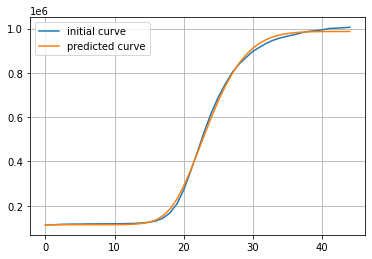

In [17]:
plt.plot(curve, label = 'initial curve')

D_e_pred = simulate_vals(D_init=Decimal(10**res.x[0]),
                    E_init=Decimal(10**res.x[1]), 
                    P_init=Decimal(10**res.x[2]), 
                    delta_e=Decimal(10**res.x[4]),
                    n_d=Decimal(10**0),
                    n_dE=Decimal(10**0),
                    k_C=Decimal(10**res.x[7]),
                    beta=Decimal(10**res.x[8]),
                    n_cycle=44)[2]

D_e_pred = np.array([float(str(x)) + 10**res.x[3] for x in D_e_pred])

plt.plot(D_e_pred, label = 'predicted curve')
plt.legend()
plt.grid()

## Validation on multiple curves

In [18]:
import pandas as pd
val_curves = pd.read_csv("data/opt_valset.csv")
val_curves.head(5)

# print(val_curves.shape)
# print(type(curve))
# print(curve.shape)

,curve_idx,target,amp_score,cq,cycle_no,rn,drn,Fn,pcr_plate,sample_type,igi_call
0,23677,MS2,2.388084,25.285821128516332,1,229219.609375,-1374.626328,229219.61,AC00DB1I,Clinical Sample,Positive
1,23677,MS2,2.388084,25.285821128516332,2,229516.937500,-1170.968546,229516.94,AC00DB1I,Clinical Sample,Positive
2,23677,MS2,2.388084,25.285821128516332,3,230569.781250,-211.795139,230569.78,AC00DB1I,Clinical Sample,Positive
3,23677,MS2,2.388084,25.285821128516332,4,231039.625000,164.378268,231039.62,AC00DB1I,Clinical Sample,Positive
4,23677,MS2,2.388084,25.285821128516332,5,230943.109375,-25.807700,230943.11,AC00DB1I,Clinical Sample,Positive


### Convert validation data into arrays

In [19]:
# Initialize an empty dictionary
curve_dict = {}

# Initialize variables to track the current cycle and array
current_cycle = None
current_array = None

# Iterate over each row in the DataFrame
for index, row in val_curves.iterrows():
    curve_idx = row['curve_idx']
    cycle_no = row['cycle_no']
    Fn = row['Fn']

    # Create a new array if cycle_no resets to 1
    if cycle_no == 1:
        current_array = []
        
    # Append Fn to the current array
    current_array.append(Fn)

    # Save the array in the dictionary with key as curve_idx
    curve_dict[curve_idx] = current_array.copy()

# Output the dictionary
print(curve_dict)

{23677: [229219.61, 229516.94, 230569.78, 231039.62, 230943.11, 230716.08, 230738.72, 231506.53, 231881.64, 231403.33, 231121.1, 231270.34, 232347.42, 232583.56, 232420.75, 232218.86, 231576.52, 231489.69, 232237.1, 232335.8, 232360.58, 233107.52, 233559.84, 234792.33, 236167.22, 239115.5, 244746.55, 251284.23, 259784.92, 269840.06, 282681.1, 297658.06, 312901.47, 329566.8, 347342.06, 364913.8, 383243.47, 399506.16, 414237.06, 426192.12], 23827: [225227.69, 225484.0, 226158.3, 226503.12, 226652.75, 227078.83, 227089.17, 227114.14, 226987.95, 226832.52, 226757.75, 226968.16, 226995.47, 227085.25, 226990.39, 226928.94, 226880.67, 226871.75, 227049.5, 227176.38, 227102.89, 227260.45, 228102.67, 229347.3, 231038.64, 234510.11, 239952.72, 247267.86, 255982.25, 267886.97, 281850.6, 297396.7, 315155.75, 334287.1, 353652.88, 374252.4, 394581.47, 413789.8, 431580.06, 445970.53], 23900: [229257.72, 229768.98, 230963.02, 231039.84, 230871.23, 230891.53, 231116.3, 231109.84, 231297.89, 231160.23, 

In [25]:
#Get target dataframe
target_data = val_curves.groupby('curve_idx').tail(1)

target_data['Igi_call_quant'] = (target_data['igi_call']=="Positive").astype(int)

print(target_data.head(5))
print(target_data['sample_type'].unique())
print(target_data.groupby('sample_type').count())

print(target_data.shape)
print(len(target_data['curve_idx'].unique()))

     curve_idx  target  amp_score                  cq  cycle_no  \
39       23677     MS2   2.388084  25.285821128516332        40   
79       23827     MS2   2.411084   25.07951713476232        40   
119      23900     MS2   2.297453  25.197460254036216        40   
159      25090  S gene   2.145592   28.70093986035272        40   
199      23975     MS2   2.163302   25.14350626845352        40   

                rn            drn         Fn pcr_plate  \
39   426192.125000  191944.745915  426192.12  AC00DB1I   
79   445970.531250  218357.165625  445970.53  AC00DB1I   
119  401292.343750  170586.391506  401292.34  AC00DB1I   
159  238620.828125   56947.925824  238620.83  AC00DB1I   
199  322850.781250   97378.915372  322850.78  AC00DB1I   

                 sample_type  igi_call  Igi_call_quant  
39           Clinical Sample  Positive               1  
79           Clinical Sample  Positive               1  
119          Clinical Sample  Positive               1  
159  Positive Contro

C:\Users\alexa\AppData\Local\Temp\ipykernel_14524\1771119116.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_data['Igi_call_quant'] = (target_data['igi_call']=="Positive").astype(int)


In [26]:
#Filter down to ground truth 
ground_truth_targets = target_data[target_data['sample_type']!='Clinical Sample']
print(ground_truth_targets.shape)

(220, 12)


### Implementing eval loop

In [58]:
ct = 0

mse_list = []
mse_list_stand = []
mse_list_stand_real = []
D_e_0_pred_list = []
D_e_0_true_list = []
D_init_pred_list = []

D_e_25_pred_list = []
D_e_25_true_list = []

D_e_40_pred_list = []
D_e_40_true_list = []

for index, row in ground_truth_targets.iterrows():
    
    #get curve corresponding to row
    curve = curve_dict[row['curve_idx']]
    # print(len(curve))
    # print(int(len(curve)))
    
    n_cycle = int(len(curve)) - 1

    # plt.plot(curve)
    
    #instantiate
    init_params = np.array([4, 6, 5, 5, 1, 0, 0, 1, 1])
    
    #perform optimization
    res = minimize(func_to_optimize, init_params, method='nelder-mead', options={'xatol': 1e-1, 'disp': True})
    
    #get the predicted curve
    D_e_pred = simulate_vals(D_init=Decimal(10**res.x[0]),
                    E_init=Decimal(10**res.x[1]), 
                    P_init=Decimal(10**res.x[2]), 
                    delta_e=Decimal(10**res.x[4]),
                    n_d=Decimal(10**0),
                    n_dE=Decimal(10**0),
                    k_C=Decimal(10**res.x[7]),
                    beta=Decimal(10**res.x[8]),
                    n_cycle=n_cycle)[2]
    
    D_init_pred = 10**res.x[0]
    D_init_pred_list.append(D_init_pred)
    
    D_e_pred = np.array([float(str(x)) + 10**res.x[3] for x in D_e_pred])
    D_e_0_pred = D_e_pred[0]
    D_e_0_pred_list.append(D_e_0_pred)
    D_e_0_true_list.append(curve[0])
    
    D_e_25_pred = D_e_pred[25]
    D_e_25_pred_list.append(D_e_25_pred)
    D_e_25_true_list.append(curve[25])
    
    D_e_40_pred = D_e_pred[40]
    D_e_40_pred_list.append(D_e_40_pred)
    D_e_40_true_list.append(curve[40])
    
    mse = ((curve - D_e_pred)**2).mean()
    mse_list.append(mse)
    
    #What is the MSE if we standardize the predicted and real curve individually, I.e. we only care about the shape match
    max_real = np.max(curve)
    max_pred = np.max(D_e_0_pred)
    
    D_e_pred_stand = D_e_pred/max_pred
    curve_stand = curve/max_real
    mse_stand = ((curve_stand - D_e_pred_stand)**2).mean()
    mse_list_stand.append(mse_stand)
    
    #what if we standardize both curves by the max of the real curve
    #Rational we care about out prediction achieving the predicted absolute viral load 
    D_e_pred_real_stand = D_e_pred/max_real
    
    mse_stand_real = ((curve_stand - D_e_pred_real_stand)**2).mean()
    mse_list_stand_real.append(mse_stand_real)
    
    
    #calculate mse relative to real curve

#     plt.plot(curve, label = 'true curve')
#     plt.plot(D_e_pred, label = 'predicted curve')
#     plt.legend()
#     plt.grid()
#     plt.show()
    
#     print(f'D_e_0_pred = {D_e_0_pred}')
#     print(f'MSE = {mse}')
#     print(f'MSE standardized indiv = {mse_stand}')
#     print(f'MSE standardized by real curve max = {mse_stand_real}')
#     print()
#     print('#####################################')

    ct += 1
#     if ct == 5:
#         break
    
ground_truth_targets['D_init_pred'] = D_init_pred_list
ground_truth_targets['D_e_0_pred'] = D_e_0_pred_list
ground_truth_targets['D_e_0_true'] = D_e_0_true_list

ground_truth_targets['D_e_25_pred'] = D_e_25_pred_list
ground_truth_targets['D_e_25_true'] = D_e_25_true_list

ground_truth_targets['D_e_40_pred'] = D_e_40_pred_list
ground_truth_targets['D_e_40_true'] = D_e_40_true_list

ground_truth_targets['mse'] = mse_list
ground_truth_targets['mse_stand'] = mse_list_stand
ground_truth_targets['mse_stand_real'] = mse_list_stand_real
    

Optimization terminated successfully.
         Current function value: 4588303095.130161
         Iterations: 662
         Function evaluations: 1027
Optimization terminated successfully.
         Current function value: 17480482.299938
         Iterations: 913
         Function evaluations: 1398
Optimization terminated successfully.
         Current function value: 66594474.266820
         Iterations: 682
         Function evaluations: 1067
Optimization terminated successfully.
         Current function value: 88632665.840755
         Iterations: 884
         Function evaluations: 1346
Optimization terminated successfully.
         Current function value: 19871.593628
         Iterations: 687
         Function evaluations: 1054
Optimization terminated successfully.
         Current function value: 10817016.700729
         Iterations: 636
         Function evaluations: 1006
Optimization terminated successfully.
         Current function value: 38881.676211
         Iterations: 721
    

Optimization terminated successfully.
         Current function value: 13464.974612
         Iterations: 713
         Function evaluations: 1100
Optimization terminated successfully.
         Current function value: 17529.418579
         Iterations: 533
         Function evaluations: 825
Optimization terminated successfully.
         Current function value: 19511697.931306
         Iterations: 636
         Function evaluations: 1003
Optimization terminated successfully.
         Current function value: 62690.969138
         Iterations: 729
         Function evaluations: 1112
Optimization terminated successfully.
         Current function value: 5798940096.160295
         Iterations: 827
         Function evaluations: 1266
Optimization terminated successfully.
         Current function value: 9157890.930064
         Iterations: 514
         Function evaluations: 832
Optimization terminated successfully.
         Current function value: 8013014.819365
         Iterations: 1141
         F

Optimization terminated successfully.
         Current function value: 6078167547.948865
         Iterations: 1003
         Function evaluations: 1769
Optimization terminated successfully.
         Current function value: 1503231.455224
         Iterations: 695
         Function evaluations: 1094
Optimization terminated successfully.
         Current function value: 38566.195840
         Iterations: 729
         Function evaluations: 1108
Optimization terminated successfully.
         Current function value: 45537186.352441
         Iterations: 507
         Function evaluations: 783
Optimization terminated successfully.
         Current function value: 42453436.656067
         Iterations: 753
         Function evaluations: 1179
Optimization terminated successfully.
         Current function value: 3555937.196776
         Iterations: 521
         Function evaluations: 835
Optimization terminated successfully.
         Current function value: 14128149.336548
         Iterations: 1011
   

Optimization terminated successfully.
         Current function value: 15222977.573995
         Iterations: 714
         Function evaluations: 1117
Optimization terminated successfully.
         Current function value: 8008922.228173
         Iterations: 792
         Function evaluations: 1231
Optimization terminated successfully.
         Current function value: 73564.022869
         Iterations: 487
         Function evaluations: 794
Optimization terminated successfully.
         Current function value: 440181.492731
         Iterations: 754
         Function evaluations: 1516
Optimization terminated successfully.
         Current function value: 1102752.994460
         Iterations: 865
         Function evaluations: 1321
Optimization terminated successfully.
         Current function value: 227879.112815
         Iterations: 795
         Function evaluations: 1203
Optimization terminated successfully.
         Current function value: 132407.521731
         Iterations: 446
         Fun

C:\Users\alexa\AppData\Local\Temp\ipykernel_14524\3076073795.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ground_truth_targets['D_init_pred'] = D_init_pred_list
C:\Users\alexa\AppData\Local\Temp\ipykernel_14524\3076073795.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ground_truth_targets['D_e_0_pred'] = D_e_0_pred_list
C:\Users\alexa\AppData\Local\Temp\ipykernel_14524\3076073795.py:94: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[r

In [63]:
ground_truth_targets.head(20)
ground_truth_targets.to_csv('230829PCR_curve_optimization_eval.csv')

Do any of the curve reconstruction measures function as a good predictor for the PCR test result?

                         curve_idx  target  amp_score   cq  cycle_no   rn  \
sample_type                                                                 
Negative Control (qPCR)        100     100        100  100       100  100   
Positive Control (qPCR)        120     120        120  120       120  120   

                         drn   Fn  pcr_plate  igi_call  Igi_call_quant  \
sample_type                                                              
Negative Control (qPCR)  100  100        100       100             100   
Positive Control (qPCR)  120  120        120       120             120   

                         D_e_0_pred  D_e_0_true  mse  mse_stand  \
sample_type                                                       
Negative Control (qPCR)         100         100  100        100   
Positive Control (qPCR)         120         120  120        120   

                         mse_stand_real  D_e_0_error  D_init_pred  \
sample_type                                             

C:\Users\alexa\AppData\Local\Temp\ipykernel_14524\4233139386.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ground_truth_targets['D_e_0_error'] = (ground_truth_targets['D_e_0_true'] - ground_truth_targets['D_e_0_pred'])**2


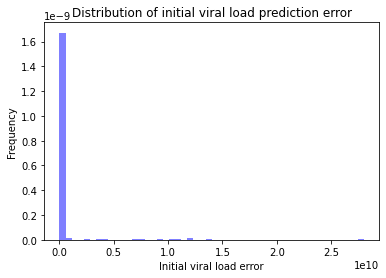

1214440.3657185077
                         curve_idx  target  amp_score  cq  cycle_no  rn  drn  \
sample_type                                                                    
Negative Control (qPCR)         78      78         78  78        78  78   78   
Positive Control (qPCR)         32      32         32  32        32  32   32   

                         Fn  pcr_plate  igi_call  Igi_call_quant  D_e_0_pred  \
sample_type                                                                    
Negative Control (qPCR)  78         78        78              78          78   
Positive Control (qPCR)  32         32        32              32          32   

                         D_e_0_true  mse  mse_stand  mse_stand_real  \
sample_type                                                           
Negative Control (qPCR)          78   78         78              78   
Positive Control (qPCR)          32   32         32              32   

                         D_e_0_error  D_init_pred  D_e

In [65]:
from sklearn.metrics import roc_auc_score, mean_squared_error

def print_performance_metrics(ground_truth_targets):
    mse = mean_squared_error(ground_truth_targets['D_e_0_true'], ground_truth_targets['D_e_0_pred'])
    print(f"MSE De0 pred: {mse}")

    auc = roc_auc_score(ground_truth_targets['Igi_call_quant'], ground_truth_targets['D_e_0_pred'])
    print(f"AUC IGI-call De0 pred: {auc}")

    auc = roc_auc_score(ground_truth_targets['Igi_call_quant'], ground_truth_targets['D_e_0_true'])
    print(f"AUC IGI-call De0 real: {auc}")
    
    auc = roc_auc_score(ground_truth_targets['Igi_call_quant'], ground_truth_targets['D_e_25_pred'])
    print(f"AUC IGI-call De25 pred: {auc}")
    
    auc = roc_auc_score(ground_truth_targets['Igi_call_quant'], ground_truth_targets['D_e_25_true'])
    print(f"AUC IGI-call De25 real: {auc}")
    
#     auc = roc_auc_score(ground_truth_targets['Igi_call_quant'], ground_truth_targets['D_e_40_pred'])
#     print(f"AUC IGI-call De40 pred: {auc}")
    
#     auc = roc_auc_score(ground_truth_targets['Igi_call_quant'], ground_truth_targets['D_e_40_true'])
#     print(f"AUC IGI-call De40 real: {auc}")

    auc = roc_auc_score(ground_truth_targets['Igi_call_quant'], ground_truth_targets['mse'])
    print(f"AUC IGI-call mse: {auc}")

    auc = roc_auc_score(ground_truth_targets['Igi_call_quant'], ground_truth_targets['mse_stand'])
    print(f"AUC IGI-call mse_stand: {auc}")

    auc = roc_auc_score(ground_truth_targets['Igi_call_quant'], ground_truth_targets['mse_stand_real'])
    print(f"AUC IGI-call mse_stand_real: {auc}")

print(ground_truth_targets.groupby(['sample_type']).count())
    
print_performance_metrics(ground_truth_targets)

ground_truth_targets['D_e_0_error'] = (ground_truth_targets['D_e_0_true'] - ground_truth_targets['D_e_0_pred'])**2

plt.hist(ground_truth_targets['D_e_0_error'], color='b', alpha=0.5, density=True, bins=50)
# Add your title, axis labels and legend here
plt.title("Distribution of initial viral load prediction error")
plt.xlabel("Initial viral load error")
plt.ylabel("Frequency")
plt.show()

print(np.median(ground_truth_targets['D_e_0_error']))

ground_truth_targets_low_recon_error = ground_truth_targets[ground_truth_targets['D_e_0_error']<np.median(ground_truth_targets['D_e_0_error'])]

print(ground_truth_targets_low_recon_error.groupby(['sample_type']).count())

print_performance_metrics(ground_truth_targets_low_recon_error)